# Линейная классификация текстов в sklearn: Logistic Regression

# Домашнее задание (RU)

Возьмите датасет на русском. Это может быть датасет из прошлой домашки (новости), или новый, например  
**`data-silence/rus_news_classifier`** (HuggingFace Datasets)

Сделайте аналогичный ноутбук:

1) Один базовый векторайзер (TF‑IDF), логрегрессия (подбор $\alpha$), метрики accuracy и macro‑F1. Подбор гиперпараметров (eta, tol, max_iter). Сделайте необходимую предобработку для "мешка слов" на русском
2) Линейный SVM (подбор C), сравнить метрики.  
3) Добавить L1-регуляризацию и вывести топ‑признаки (слова/n‑граммы) для 2–3 классов.  
4) (Бонус) Попробовать **char n‑grams TF‑IDF** и сравнить с word TF‑IDF.

Сдача: таблица результатов + 3-5 предложений выводов.


In [33]:
# --- Импорты ---
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, log_loss, ConfusionMatrixDisplay

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

np.random.seed(7)


In [34]:
final_results = []


# Был выбран датасет с категориями: https://huggingface.co/datasets/data-silence/rus_news_classifier

In [35]:
from datasets import load_dataset

ds = load_dataset("data-silence/rus_news_classifier")

#  7 - science, 9 - sports
text_science = [i["news"] for i in ds["train"] if i["labels"] == 7]
text_sports  = [i["news"] for i in ds["train"] if i["labels"] == 9]

X_text = np.array(text_science + text_sports, dtype=object)
y = np.array([0]*len(text_science) + [1]*len(text_sports))

print("Всего документов:", len(X_text))
print("Баланс классов:", dict(zip(*np.unique(y, return_counts=True))))

Всего документов: 10197
Баланс классов: {np.int64(0): np.int64(5406), np.int64(1): np.int64(4791)}


In [36]:
# --- split train/val/test ---
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_text, y, test_size=0.30, random_state=7, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=7, stratify=y_tmp
)

print("train:", len(X_train), "val:", len(X_val), "test:", len(X_test))


train: 7137 val: 1530 test: 1530


1. Один базовый векторайзер (TF‑IDF), логрегрессия (подбор  α ), метрики accuracy и macro‑F1. Подбор гиперпараметров (eta, tol, max_iter). Сделайте необходимую предобработку для "мешка слов" на русском

In [37]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
ru_stop = stopwords.words("russian")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
pip install pymorphy3


In [39]:
from functools import lru_cache
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")

@lru_cache(maxsize=200_000)
def lemma_cached(w: str) -> str:
    return morph.parse(w)[0].normal_form

def simple_tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(text.lower())

def tokenize_lemmas(text: str) -> list[str]:
    token = []
    words = simple_tokenize(text)
    for w in words:
        if w in ru_stop:
            continue
        lemma = lemma_cached(w)
        if lemma in ru_stop:
            continue
        token.append(lemma)
    return token

In [40]:
pipe_sgd_lr = Pipeline([
    ("vec", TfidfVectorizer(
        tokenizer=tokenize_lemmas,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        ngram_range=(1, 2),
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-5,                 # будем подбирать
        learning_rate="constant",
        eta0=0.02,
        max_iter=30,                # эпохи (внутри .fit)
        tol=1e-6,
        random_state=7
    ))
])

In [41]:
alphas = [1e-6, 1e-5, 1e-4]
results = []

for a in alphas:
    model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=a,
            learning_rate="constant",
            eta0=0.02,
            max_iter=30,
            tol=1e-6,
            random_state=7
        ))
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")
    results.append((a, acc, f1))

# выбираем лучший по macro-F1
best_alpha, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (alpha, acc_val, f1_val):")
for a, acc, f1 in results:
    print(f"alpha={a:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")

print("\nЛучший alpha:", best_alpha, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (alpha, acc_val, f1_val):
alpha=1e-06     acc_val=0.998  f1_val=0.998
alpha=1e-05     acc_val=0.998  f1_val=0.998
alpha=0.0001    acc_val=0.998  f1_val=0.998

Лучший alpha: 1e-06 | acc_val: 0.9980392156862745 | f1_val: 0.9980316269096756


In [42]:
etas = [0.005, 0.01, 0.02, 0.05]
results = []

for eta in etas:
  model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=eta,
            max_iter=30,
            tol=1e-6,
            random_state=7
        ))
    ])
  model.fit(X_train, y_train)
  y_val_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_val_pred)
  f1  = f1_score(y_val, y_val_pred, average="macro")
  results.append((eta, acc, f1))

# выбираем лучший по macro-F1
best_eta, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (eta, acc_val, f1_val):")
for e, acc, f1 in results:
    print(f"eta={e:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")


print("\nЛучший eta:", best_eta, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (eta, acc_val, f1_val):
eta=0.005     acc_val=0.998  f1_val=0.998
eta=0.01      acc_val=0.998  f1_val=0.998
eta=0.02      acc_val=0.998  f1_val=0.998
eta=0.05      acc_val=0.998  f1_val=0.998

Лучший eta: 0.005 | acc_val: 0.9980392156862745 | f1_val: 0.9980316269096756


In [43]:
tols      = [1e-3, 1e-4, 1e-6]
results = []

for t in tols:
  model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=best_eta,
            max_iter=30,
            tol=t,
            random_state=7
        ))
    ])
  model.fit(X_train, y_train)
  y_val_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_val_pred)
  f1  = f1_score(y_val, y_val_pred, average="macro")
  results.append((t, acc, f1))
 # выбираем лучший по macro-F1
best_tol, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (tol, acc_val, f1_val):")
for t, acc, f1 in results:
    print(f"tol={t:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")


print("\nЛучший tol:", best_tol, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (tol, acc_val, f1_val):
tol=0.001     acc_val=0.998  f1_val=0.998
tol=0.0001    acc_val=0.998  f1_val=0.998
tol=1e-06     acc_val=0.998  f1_val=0.998

Лучший tol: 0.001 | acc_val: 0.9980392156862745 | f1_val: 0.9980316269096756


In [44]:
max_iters = [15, 30, 50]
results = []

for i in max_iters:
  model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=best_eta,
            max_iter=i,
            tol=best_tol,
            random_state=7
        ))
    ])
  model.fit(X_train, y_train)
  y_val_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_val_pred)
  f1  = f1_score(y_val, y_val_pred, average="macro")
  results.append((i, acc, f1))
best_max_iter, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (tol, acc_val, f1_val):")
for i, acc, f1 in results:
    print(f"best_max_iter={i:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")


print("\nЛучший max_iter:", best_max_iter, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (tol, acc_val, f1_val):
best_max_iter=15        acc_val=0.998  f1_val=0.998
best_max_iter=30        acc_val=0.998  f1_val=0.998
best_max_iter=50        acc_val=0.998  f1_val=0.998

Лучший max_iter: 15 | acc_val: 0.9980392156862745 | f1_val: 0.9980316269096756


In [45]:
# --- Финальная модель с best_alpha ---
best_sgd_lr = Pipeline([
    ("vec", TfidfVectorizer(
        tokenizer=tokenize_lemmas,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        max_df=0.9,
        ngram_range=(1, 2),
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=best_alpha,
        learning_rate="constant",
        eta0=best_eta,
        max_iter=best_max_iter,
        tol=best_tol,
        random_state=7
    ))
])
best_sgd_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('vec',
                 TfidfVectorizer(lowercase=False, max_df=0.9, min_df=3,
                                 ngram_range=(1, 2), token_pattern=None,
                                 tokenizer=<function tokenize_lemmas at 0x78193a966700>)),
                ('clf',
                 SGDClassifier(alpha=1e-06, eta0=0.005,
                               learning_rate='constant', loss='log_loss',
                               max_iter=15, random_state=7))])

In [46]:
# --- Оценка на val/test для лучшей модели ---
y_val_pred = best_sgd_lr.predict(X_val)
y_test_pred = best_sgd_lr.predict(X_test)


print("VAL accuracy:", accuracy_score(y_val, y_val_pred))
print("VAL macro-F1:", f1_score(y_val, y_val_pred, average="macro"))
print()
print("TEST accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST macro-F1:", f1_score(y_test, y_test_pred, average="macro"))
print("\nОтчёт (test):\n", classification_report(y_test, y_test_pred, target_names=["science", "sports"]))

acc_test = accuracy_score(y_test, y_test_pred)
f1_test  = f1_score(y_test, y_test_pred, average="macro")

final_results.append({
    "Model": "SGD Logistic (Pipeline, L2)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})


VAL accuracy: 0.9980392156862745
VAL macro-F1: 0.9980316269096756

TEST accuracy: 0.9973856209150327
TEST macro-F1: 0.9973757152462368

Отчёт (test):
               precision    recall  f1-score   support

     science       1.00      1.00      1.00       811
      sports       1.00      1.00      1.00       719

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530



In [47]:
final_results

[{'Model': 'SGD Logistic (Pipeline, L2)',
  'Accuracy (test)': 0.9973856209150327,
  'Macro-F1 (test)': 0.9973757152462368}]

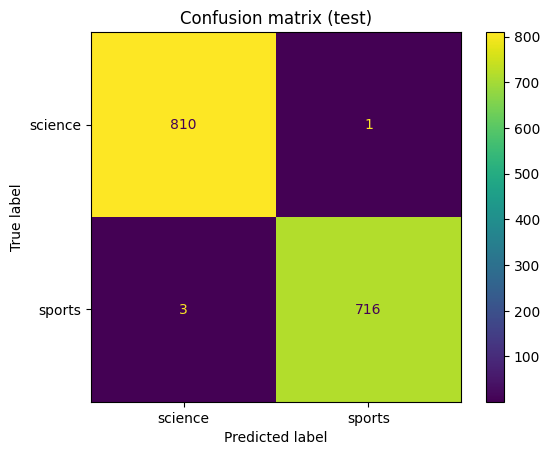

In [48]:
# --- Confusion matrix (test) ---
disp = ConfusionMatrixDisplay.from_estimator(best_sgd_lr, X_test, y_test, display_labels=["science", "sports"])
plt.title("Confusion matrix (test)")
plt.grid(False)
plt.show()

In [49]:
# --- Подготовка: векторизуем отдельно (чтобы быстро считать loss) ---
print("best_alpha =", best_alpha)

vec = best_sgd_lr.named_steps["vec"]
Xtr = vec.transform(X_train)
Xva = vec.transform(X_val)

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=best_alpha,
    learning_rate="constant",
    eta0=0.02,
    random_state=7
)

classes = np.array([0, 1])


best_alpha = 1e-06


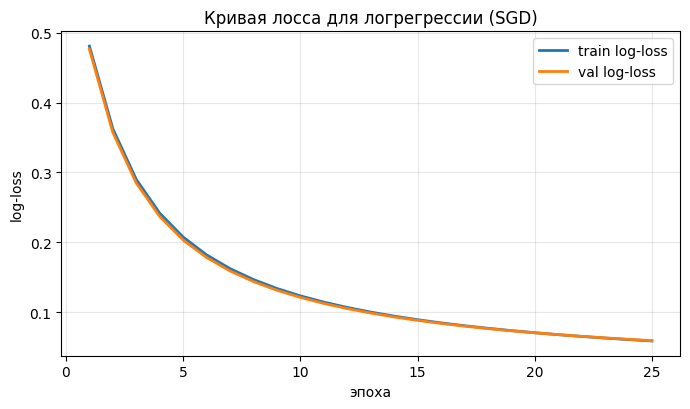

In [50]:
# --- Обучение по эпохам + логирование log-loss ---
epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    # partial_fit: одна эпоха SGD на всей обучающей матрице
    if epoch == 0:
        sgd.partial_fit(Xtr, y_train, classes=classes)
    else:
        sgd.partial_fit(Xtr, y_train)

    # вероятности нужны для log_loss
    p_tr = sgd.predict_proba(Xtr)
    p_va = sgd.predict_proba(Xva)

    train_losses.append(log_loss(y_train, p_tr))
    val_losses.append(log_loss(y_val, p_va))

plt.figure(figsize=(7, 4.2))
plt.plot(range(1, epochs+1), train_losses, linewidth=2, label="train log-loss")
plt.plot(range(1, epochs+1), val_losses, linewidth=2, label="val log-loss")
plt.xlabel("эпоха")
plt.ylabel("log-loss")
plt.title("Кривая лосса для логрегрессии (SGD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
# --- Accuracy и F1 для SGD-логрегрессии (на val/test) ---
Xte = vec.transform(X_test)

y_val_pred_sgd = sgd.predict(Xva)
y_test_pred_sgd = sgd.predict(Xte)

print("SGD VAL accuracy:", accuracy_score(y_val, y_val_pred_sgd))
print("SGD VAL macro-F1:", f1_score(y_val, y_val_pred_sgd, average="macro"))
print()
print("SGD TEST accuracy:", accuracy_score(y_test, y_test_pred_sgd))
print("SGD TEST macro-F1:", f1_score(y_test, y_test_pred_sgd, average="macro"))

acc_test = accuracy_score(y_test, y_test_pred_sgd)
f1_test  = f1_score(y_test, y_test_pred_sgd, average="macro")

final_results.append({
    "Model": "SGD Logistic (partial_fit, L2)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})

SGD VAL accuracy: 0.9980392156862745
SGD VAL macro-F1: 0.9980316269096756

SGD TEST accuracy: 0.9986928104575163
SGD TEST macro-F1: 0.9986880668965836


In [52]:
final_results

[{'Model': 'SGD Logistic (Pipeline, L2)',
  'Accuracy (test)': 0.9973856209150327,
  'Macro-F1 (test)': 0.9973757152462368},
 {'Model': 'SGD Logistic (partial_fit, L2)',
  'Accuracy (test)': 0.9986928104575163,
  'Macro-F1 (test)': 0.9986880668965836}]

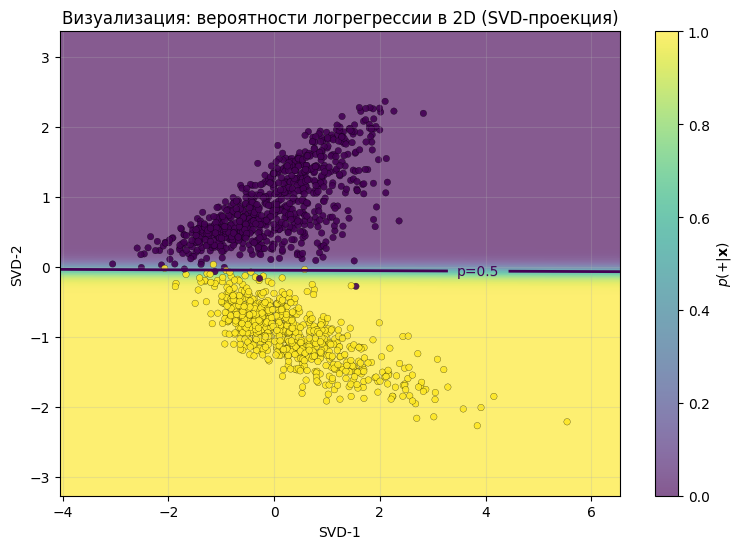

In [53]:
# --- 2D проекция TF-IDF -> SVD ---
svd = TruncatedSVD(n_components=2, random_state=7)
Xtr_2d = svd.fit_transform(Xtr)
Xva_2d = svd.transform(Xva)

# Небольшая стандартизация помогает для красивых границ
sc = StandardScaler()
Xtr_2d = sc.fit_transform(Xtr_2d)
Xva_2d = sc.transform(Xva_2d)

lr_2d = SGDClassifier(loss="log_loss", penalty="l2", alpha=best_alpha,
                     learning_rate="constant", eta0=0.02, max_iter=2000,
                     tol=1e-6, random_state=7)
lr_2d.fit(Xtr_2d, y_train)

# --- сетка для heatmap ---
x_min, x_max = Xva_2d[:, 0].min() - 1.0, Xva_2d[:, 0].max() + 1.0
y_min, y_max = Xva_2d[:, 1].min() - 1.0, Xva_2d[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]

proba = lr_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(7.8, 5.6))
im = plt.imshow(
    proba, origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    aspect="auto", alpha=0.65,
    vmin=0.0, vmax=1.0
)
plt.colorbar(im, label=r"$p(+|\mathbf{x})$")

# граница p=0.5
cs = plt.contour(xx, yy, proba, levels=[0.5], linewidths=2)
plt.clabel(cs, fmt={0.5: "p=0.5"})

# точки валидации
plt.scatter(Xva_2d[:, 0], Xva_2d[:, 1], c=y_val, s=22, edgecolors="black", linewidths=0.2, alpha=0.9)

plt.title("Визуализация: вероятности логрегрессии в 2D (SVD-проекция)")
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


2) Линейный SVM (подбор C), сравнить метрики.

In [54]:
from sklearn.svm import LinearSVC

Cs = [0.01, 0.1, 1, 3, 10, 30, 100]
svm_results = []

for C in Cs:
    svm = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            max_df=0.9,
            ngram_range=(1, 2),
        )),
        ("clf", LinearSVC(C=C, random_state=7))
    ])

    svm.fit(X_train, y_train)
    y_val_pred = svm.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")
    svm_results.append((C, acc, f1))

best_C, best_acc, best_f1 = sorted(svm_results, key=lambda x: x[2], reverse=True)[0]

print("SVM результаты (C, acc_val, f1_val):")
for C, acc, f1 in svm_results:
    print(f"C={C:<6g}  acc_val={acc:.3f}  f1_val={f1:.3f}")

print("\nЛучший C:", best_C, "| acc_val:", best_acc, "| f1_val:", best_f1)

# финальная модель (обучаем на train и проверяем на test)
best_svm = Pipeline([
    ("vec", TfidfVectorizer(
        tokenizer=tokenize_lemmas,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        max_df=0.9,
        ngram_range=(1, 2),
    )),
    ("clf", LinearSVC(C=best_C, random_state=7))
])

best_svm.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM результаты (C, acc_val, f1_val):
C=0.01    acc_val=0.997  f1_val=0.997
C=0.1     acc_val=0.998  f1_val=0.998
C=1       acc_val=0.999  f1_val=0.999
C=3       acc_val=0.999  f1_val=0.999
C=10      acc_val=0.999  f1_val=0.999
C=30      acc_val=0.999  f1_val=0.999
C=100     acc_val=0.999  f1_val=0.999

Лучший C: 1 | acc_val: 0.9993464052287582 | f1_val: 0.9993439814153794


Pipeline(steps=[('vec',
                 TfidfVectorizer(lowercase=False, max_df=0.9, min_df=3,
                                 ngram_range=(1, 2), token_pattern=None,
                                 tokenizer=<function tokenize_lemmas at 0x78193a966700>)),
                ('clf', LinearSVC(C=1, random_state=7))])

In [55]:
# --- Оценка на val/test для лучшей модели ---
y_val_pred = best_svm.predict(X_val)
y_test_pred = best_svm.predict(X_test)

print("VAL accuracy:", accuracy_score(y_val, y_val_pred))
print("VAL macro-F1:", f1_score(y_val, y_val_pred, average="macro"))
print()
print("TEST accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST macro-F1:", f1_score(y_test, y_test_pred, average="macro"))
print("\nОтчёт (test):\n", classification_report(y_test, y_test_pred, target_names=["science", "sports"]))

acc_test = accuracy_score(y_test, y_test_pred)
f1_test  = f1_score(y_test, y_test_pred, average="macro")

final_results.append({
    "Model": "LinearSVC (best_svm)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})

VAL accuracy: 0.9993464052287582
VAL macro-F1: 0.9993439814153794

TEST accuracy: 1.0
TEST macro-F1: 1.0

Отчёт (test):
               precision    recall  f1-score   support

     science       1.00      1.00      1.00       811
      sports       1.00      1.00      1.00       719

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530



In [56]:
final_results

[{'Model': 'SGD Logistic (Pipeline, L2)',
  'Accuracy (test)': 0.9973856209150327,
  'Macro-F1 (test)': 0.9973757152462368},
 {'Model': 'SGD Logistic (partial_fit, L2)',
  'Accuracy (test)': 0.9986928104575163,
  'Macro-F1 (test)': 0.9986880668965836},
 {'Model': 'LinearSVC (best_svm)',
  'Accuracy (test)': 1.0,
  'Macro-F1 (test)': 1.0}]

3) Добавить L1-регуляризацию и вывести топ‑признаки (слова/n‑граммы) для 2–3 классов.  

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

models_by_alpha = {}   # alpha -> обученная модель (Pipeline)
results_l1 = []        # (alpha, acc, f1, sparsity)

for a in alphas:
    model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            max_df=0.9,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l1",
            alpha=a,
            learning_rate="constant",
            eta0=0.02,
            max_iter=50,
            tol=1e-6,
            random_state=7
        ))
    ])

    model.fit(X_train, y_train)
    models_by_alpha[a] = model  # сохраняем модель

    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")

    coef = model.named_steps["clf"].coef_.ravel()
    sparsity = (coef == 0).mean()

    results_l1.append((a, acc, f1, sparsity))

print("alpha       acc_val   f1_val   sparsity")
for a, acc, f1, sp in results_l1:
    print(f"{a:<10g} {acc:>7.3f} {f1:>8.3f} {sp:>10.3f}")

# лучший по F1
best_alpha = max(results_l1, key=lambda x: x[2])[0]
best_l1 = models_by_alpha[best_alpha]
print("\nЛучший alpha по F1:", best_alpha)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


alpha       acc_val   f1_val   sparsity
1e-06        0.998    0.998      0.043
1e-05        0.998    0.998      0.765
0.0001       0.999    0.999      0.981
0.001        0.986    0.986      0.999
0.01         0.530    0.346      1.000

Лучший alpha по F1: 0.0001


In [58]:
best_balanced_alpha_l1, best_balanced_acc_l1, best_balanced_f1_l1, best_balanced_sp_l1 = results_l1[2]
best_balanced_l1 = models_by_alpha[best_balanced_alpha_l1]
print("\nСбалансированный alpha по F1:", best_balanced_alpha_l1, "| f1_val:", best_balanced_f1_l1, "| sparsity:", best_balanced_sp_l1)


Сбалансированный alpha по F1: 0.0001 | f1_val: 0.9986878576231184 | sparsity: 0.9805865947246578


In [59]:
y_test_pred_l1 = best_balanced_l1.predict(X_test)
print("TEST accuracy (L1):", accuracy_score(y_test, y_test_pred_l1))
print("TEST macro-F1 (L1):", f1_score(y_test, y_test_pred_l1, average="macro"))

acc_test = accuracy_score(y_test, y_test_pred_l1)
f1_test  = f1_score(y_test, y_test_pred_l1, average="macro")

final_results.append({
    "Model": "SGD Logistic (L1)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})


TEST accuracy (L1): 0.9967320261437909
TEST macro-F1 (L1): 0.9967204245528309


In [60]:
final_results

[{'Model': 'SGD Logistic (Pipeline, L2)',
  'Accuracy (test)': 0.9973856209150327,
  'Macro-F1 (test)': 0.9973757152462368},
 {'Model': 'SGD Logistic (partial_fit, L2)',
  'Accuracy (test)': 0.9986928104575163,
  'Macro-F1 (test)': 0.9986880668965836},
 {'Model': 'LinearSVC (best_svm)',
  'Accuracy (test)': 1.0,
  'Macro-F1 (test)': 1.0},
 {'Model': 'SGD Logistic (L1)',
  'Accuracy (test)': 0.9967320261437909,
  'Macro-F1 (test)': 0.9967204245528309}]

In [61]:
# --- Важные признаки (топ-слова) ---
vec_l1 = best_balanced_l1.named_steps["vec"]
clf_l1 = best_balanced_l1.named_steps["clf"]

feature_names = np.array(vec_l1.get_feature_names_out())
coef = clf_l1.coef_.ravel()  # shape (n_features,)

# Сколько весов стало ровно 0?
zero_frac = (coef == 0).mean()
print(f"Доля нулевых весов (sparsity): {zero_frac:.3f}")

top_k = 20

pos_idx = np.argsort(coef)[-top_k:][::-1]
neg_idx = np.argsort(coef)[:top_k]

print("\nТоп признаков, которые увеличивают p(y=1):")
for w, c in zip(feature_names[pos_idx], coef[pos_idx]):
    print(f"{w:>20s}  {c: .3f}")

print("\nТоп признаков, которые увеличивают p(y=0):")
for w, c in zip(feature_names[neg_idx], coef[neg_idx]):
    print(f"{w:>20s}  {c: .3f}")


Доля нулевых весов (sparsity): 0.981

Топ признаков, которые увеличивают p(y=1):
           спортсмен   8.340
         олимпийский   7.122
                матч   6.167
           чемпионат   5.917
              турнир   5.609
                клуб   5.386
             сборная   5.214
         спортсменка   5.149
             чемпион   4.951
             команда   4.844
              победа   4.563
                лига   4.562
              тренер   4.486
              летний   4.426
           россиянин   4.094
            поединок   3.992
           олимпиада   3.904
                боец   3.782
        соревнование   3.601
               спорт   3.550

Топ признаков, которые увеличивают p(y=0):
            компания  -7.748
              учёный  -5.599
         космический  -5.305
               новый  -5.108
             система  -4.516
            смартфон  -4.443
             который  -4.164
          специалист  -4.018
        пользователь  -3.844
          устройство  -3.531
     

In [62]:
import pandas as pd

df_final = pd.DataFrame(final_results)
df_final = df_final.sort_values("Macro-F1 (test)", ascending=False).reset_index(drop=True)

df_final

,Model,Accuracy (test),Macro-F1 (test)
0,LinearSVC (best_svm),1.000000,1.000000
1,"SGD Logistic (partial_fit, L2)",0.998693,0.998688
2,"SGD Logistic (Pipeline, L2)",0.997386,0.997376
3,SGD Logistic (L1),0.996732,0.996720


## Вывод
Лучший результат на тестовой выборке показала модель LinearSVC, достигнув Accuracy = 1.000 и Macro-F1 = 1.000.
Модели логистической регрессии (SGD с L1 и L2) также продемонстрировали очень высокое качество, незначительно уступая SVM.
Разница между вариантами регуляризации минимальна, однако L2 показала немного более стабильный результат.
